# 02. Unsupervised Learning: Clustering y Reducción de Dimensionalidad

## Introducción

Este notebook aplica técnicas de **aprendizaje no supervisado** sobre el dataset de reseñas de productos cosméticos de Sephora con dos objetivos principales:

1. **Clustering (K-Means):** Identificar agrupaciones naturales entre los usuarios/reseñas sin utilizar la variable objetivo `is_recommended`.
2. **Reducción de dimensionalidad (PCA):** Visualizar la estructura interna de los datos en 2D y entender qué componentes concentran mayor varianza.

> **Nota metodológica:** Se trabaja con `X_train_processed.pkl` (datos ya preprocesados por el pipeline de `data_preprocessing.py`), lo que garantiza que el análisis sea consistente con el resto del proyecto y libre de data leakage.


## 1. Configuración del entorno e importación de librerías

Se importan las herramientas necesarias para:
- Manipulación de datos (`pandas`, `numpy`)
- Carga de artefactos serializados (`joblib`)
- Clustering (`KMeans`)
- Reducción de dimensionalidad (`PCA`)
- Evaluación de clusters (`silhouette_score`)
- Visualización (`matplotlib`, `seaborn`)


In [1]:
# Manipulación de datos
import warnings
import numpy as np
import pandas as pd

# Carga de artefactos
import joblib

# Manejo de rutas
from pathlib import Path

# Modelos de clustering y reducción de dimensionalidad
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# Guardado de resultados
import json
import os

# Visualización
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Se ocultan advertencias para mantener el notebook limpio
warnings.filterwarnings("ignore")

# Estilo consistente con el resto del proyecto
sns.set_context("talk")
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.titlesize": 18,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    },
)
plt.rcParams["figure.figsize"] = (10, 6)

# Semilla global para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 2. Carga de datos preprocesados

Se cargan los artefactos generados por el pipeline de preprocesamiento (`data_preprocessing.py`):
- `X_train_processed.pkl`: matriz de features ya escalada y codificada.
- `y_train.pkl`: variable objetivo (se usa solo para análisis descriptivo posterior, **no** para entrenar el clustering).

Usar los datos ya procesados garantiza consistencia con el modelado supervisado y evita reescalar dos veces.


In [2]:
# ---------------------------
# Definición de rutas
# ---------------------------

# Se sube un nivel desde /notebooks hasta la raíz del proyecto
BASE_DIR = Path.cwd().parent
data_dir = BASE_DIR / "data" / "processed"
results_dir = BASE_DIR / "results"

# Rutas de los artefactos
X_train_path = data_dir / "X_train_processed.pkl"
y_train_path = data_dir / "y_train.pkl"

# Verificación defensiva de existencia
for p in [X_train_path, y_train_path]:
    if not p.exists():
        raise FileNotFoundError(
            f"No se encontró: {p}\n"
            "Asegúrate de haber ejecutado el pipeline de preprocesamiento antes de correr este notebook."
        )

# ---------------------------
# Carga de artefactos
# ---------------------------

X_train = joblib.load(X_train_path)
y_train  = joblib.load(y_train_path)

# Convertir a numpy array para compatibilidad con sklearn
X = np.asarray(X_train)
y = np.asarray(y_train)

# ---------------------------
# Verificación de dimensiones
# ---------------------------

print("X_train shape:", X.shape)
print("y_train shape:", y.shape)
print(f"\nValores nulos en X: {np.isnan(X).sum()}")
print(f"Tipo de datos: {X.dtype}")


X_train shape: (741138, 385)
y_train shape: (741138,)

Valores nulos en X: 0
Tipo de datos: float32


## 3. Preparación de la muestra de trabajo

Dado que el dataset tiene más de un millón de registros, entrenar K-Means sobre la totalidad resulta computacionalmente costoso. Se utiliza una **muestra estratificada de 50.000 observaciones** que mantiene la proporción de clases, asegurando representatividad.

Esta muestra se usará para:
- Buscar el K óptimo (Elbow + Silhouette)
- Entrenar el modelo K-Means final
- Aplicar PCA para visualización


In [3]:
# ---------------------------
# Muestra estratificada
# ---------------------------

SAMPLE_SIZE = 50_000

# Se usa la clase 1 de y para estratificar (mantener proporción de recomendados/no recomendados)
from sklearn.model_selection import train_test_split

X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Muestra de trabajo: {X_sample.shape[0]:,} registros × {X_sample.shape[1]} features")
print(f"Distribución de clases en muestra:")
unique, counts = np.unique(y_sample, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Clase {u}: {c:,} ({c/len(y_sample)*100:.1f}%)")


Muestra de trabajo: 50,000 registros × 385 features
Distribución de clases en muestra:
  Clase 0.0: 8,002 (16.0%)
  Clase 1.0: 41,998 (84.0%)


## 4. Búsqueda del número óptimo de clusters (K)

Para determinar el valor de K más adecuado se evalúan dos métricas complementarias sobre el rango K = 2 … 10:

| Métrica | Qué mide | Criterio de selección |
|---|---|---|
| **Inertia (Elbow)** | Suma de distancias intra-cluster | Punto donde la curva forma un "codo" |
| **Silhouette Score** | Separación inter vs intra-cluster (rango −1 a 1) | Valor más alto |

Usar ambas métricas juntas reduce el riesgo de elegir un K subóptimo.


In [4]:
# ---------------------------
# Evaluación de K = 2 a 10
# ---------------------------

k_values  = list(range(2, 11))
inertias  = []
silhouettes = []

print("Evaluando K-Means para distintos valores de K...")
print("-" * 40)

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_sample)

    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_sample, labels, sample_size=10_000, random_state=RANDOM_STATE)
    silhouettes.append(sil)

    print(f"  K={k:2d}  |  Inertia={kmeans.inertia_:,.0f}  |  Silhouette={sil:.4f}")

# Consolidar resultados
k_results = pd.DataFrame({
    "k":          k_values,
    "inertia":    inertias,
    "silhouette": silhouettes,
})

print("\nResumen:")
print(k_results.to_string(index=False))


Evaluando K-Means para distintos valores de K...
----------------------------------------
  K= 2  |  Inertia=1,240,248  |  Silhouette=0.2200
  K= 3  |  Inertia=1,191,078  |  Silhouette=0.1107
  K= 4  |  Inertia=1,106,037  |  Silhouette=0.1130
  K= 5  |  Inertia=1,071,515  |  Silhouette=0.0899
  K= 6  |  Inertia=1,031,374  |  Silhouette=0.0618
  K= 7  |  Inertia=992,190  |  Silhouette=0.0668
  K= 8  |  Inertia=888,305  |  Silhouette=0.1019
  K= 9  |  Inertia=871,767  |  Silhouette=0.1031
  K=10  |  Inertia=841,424  |  Silhouette=0.1016

Resumen:
 k      inertia  silhouette
 2 1240247.5000    0.219987
 3 1191078.5000    0.110743
 4 1106036.7500    0.112954
 5 1071514.8750    0.089878
 6 1031373.6250    0.061824
 7  992190.1875    0.066759
 8  888305.2500    0.101857
 9  871767.4375    0.103147
10  841424.3750    0.101646


### 4.1 Visualización: Elbow Method y Silhouette Score


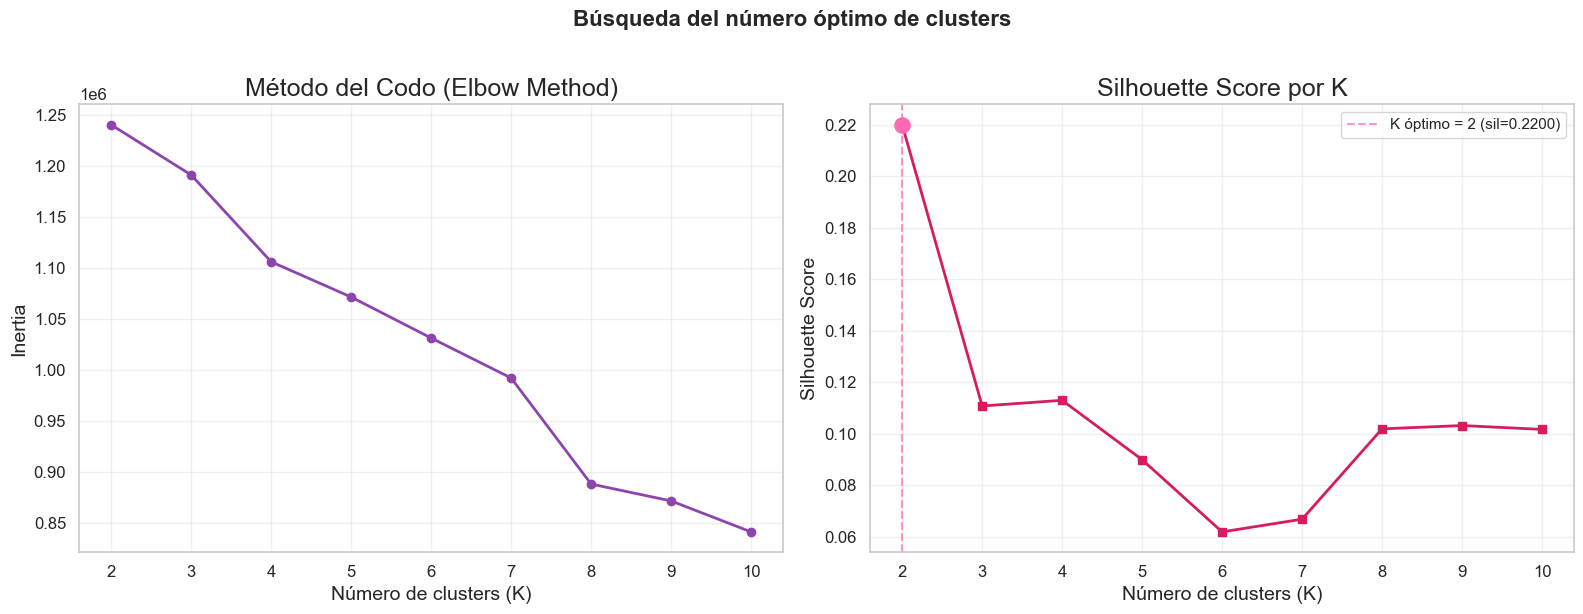


K seleccionado: 2 (Silhouette Score = 0.2200)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Gráfico 1: Elbow Method ──
axes[0].plot(k_results["k"], k_results["inertia"], marker="o", color="#8e44ad", linewidth=2)
axes[0].set_title("Método del Codo (Elbow Method)")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(k_results["k"])
axes[0].grid(True, alpha=0.3)

# ── Gráfico 2: Silhouette Score ──
axes[1].plot(k_results["k"], k_results["silhouette"], marker="s", color="#d81b60", linewidth=2)
# Marcar el K óptimo
best_k = int(k_results.loc[k_results["silhouette"].idxmax(), "k"])
best_sil = k_results.loc[k_results["silhouette"].idxmax(), "silhouette"]
axes[1].axvline(x=best_k, linestyle="--", color="#ff69b4", alpha=0.7,
                label=f"K óptimo = {best_k} (sil={best_sil:.4f})")
axes[1].scatter([best_k], [best_sil], color="#ff69b4", zorder=5, s=120)
axes[1].set_title("Silhouette Score por K")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(k_results["k"])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Búsqueda del número óptimo de clusters", y=1.02, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nK seleccionado: {best_k} (Silhouette Score = {best_sil:.4f})")


### 4.2 Interpretación

- **Elbow Method:** La inercia disminuye a medida que K aumenta. El "codo" visible indica el punto donde añadir más clusters ya no aporta mejora significativa en la compactación interna.
- **Silhouette Score:** Valores cercanos a 1 indican clusters bien separados y cohesionados. El K con mayor score es el candidato más sólido.

Se selecciona el **K con mayor Silhouette Score**, que equilibra separación y cohesión de los grupos.


## 5. Entrenamiento final del modelo K-Means

Se entrena el modelo definitivo con el K óptimo identificado. Se asigna una etiqueta de cluster a cada observación de la muestra de trabajo.


In [6]:
# ---------------------------
# Modelo K-Means final
# ---------------------------

kmeans_final = KMeans(
    n_clusters=best_k,
    n_init=15,           # Mayor estabilidad: más inicializaciones
    max_iter=500,
    random_state=RANDOM_STATE,
)

cluster_labels = kmeans_final.fit_predict(X_sample)

# ---------------------------
# Agregar etiquetas al df de análisis
# ---------------------------

df_analysis = pd.DataFrame(X_sample)
df_analysis["cluster"]        = cluster_labels
df_analysis["is_recommended"] = y_sample

# ---------------------------
# Distribución de clusters
# ---------------------------

print(f"Modelo entrenado con K = {best_k}")
print(f"Inertia final: {kmeans_final.inertia_:,.2f}")
print(f"Iteraciones hasta convergencia: {kmeans_final.n_iter_}")
print("\nDistribución de clusters:")
dist = pd.Series(cluster_labels).value_counts().sort_index()
for cluster_id, count in dist.items():
    print(f"  Cluster {cluster_id}: {count:,} obs. ({count/len(cluster_labels)*100:.1f}%)")


Modelo entrenado con K = 2
Inertia final: 1,233,025.25
Iteraciones hasta convergencia: 13

Distribución de clusters:
  Cluster 0: 4,060 obs. (8.1%)
  Cluster 1: 45,940 obs. (91.9%)


## 6. Análisis de Silhouette por cluster

El diagrama de Silhouette muestra el coeficiente individual de cada observación dentro de su cluster. Un buen clustering presenta barras uniformes y sin valores negativos significativos.


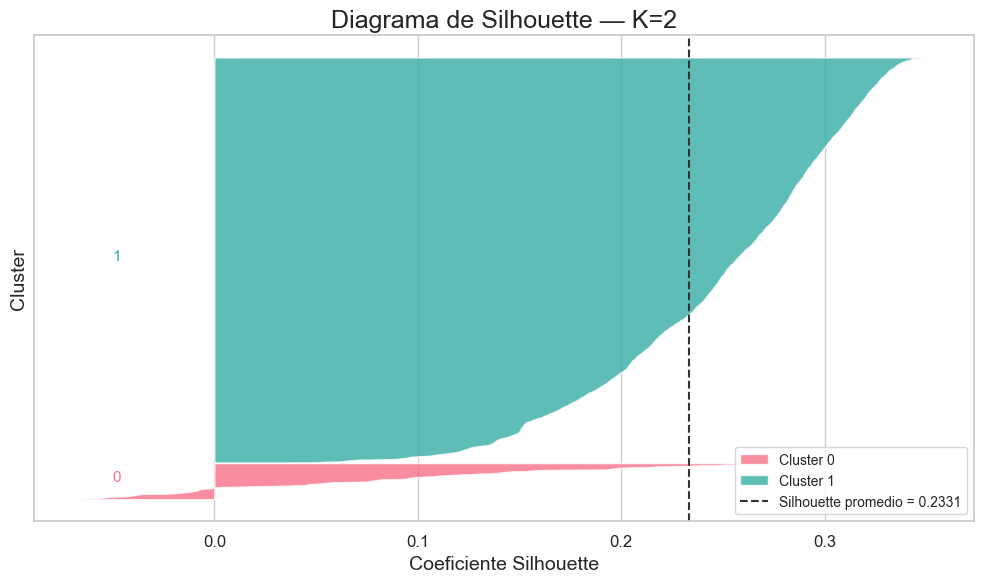

In [7]:
# ---------------------------
# Silhouette por observación
# ---------------------------

# Para no saturar el gráfico, usamos una sub-muestra de 8.000 obs.
rng   = np.random.default_rng(RANDOM_STATE)
idx   = rng.choice(len(X_sample), size=8_000, replace=False)
X_sub = X_sample[idx]
y_sub = cluster_labels[idx]

sil_vals = silhouette_samples(X_sub, y_sub)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("husl", best_k)

y_lower = 10
for i in range(best_k):
    cluster_sil = np.sort(sil_vals[y_sub == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[i], alpha=0.8, label=f"Cluster {i}")
    ax.text(-0.05, y_lower + 0.5 * size_i, str(i), fontsize=11, color=colors[i])
    y_lower = y_upper + 10

avg_sil = sil_vals.mean()
ax.axvline(x=avg_sil, color="#333", linestyle="--", linewidth=1.5,
           label=f"Silhouette promedio = {avg_sil:.4f}")

ax.set_xlabel("Coeficiente Silhouette")
ax.set_ylabel("Cluster")
ax.set_title(f"Diagrama de Silhouette — K={best_k}")
ax.set_yticks([])
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()


## 7. Reducción de dimensionalidad con PCA

El dataset procesado tiene alta dimensionalidad (muchas features). Para visualizar los clusters en un plano bidimensional se aplica **PCA** (Principal Component Analysis), que transforma las features originales en componentes principales ordenados por varianza explicada.

Se utilizan **2 componentes principales (PC1 y PC2)** para la visualización y además se analiza la varianza acumulada para entender cuánta información se retiene.


Componentes para retener 90% de varianza: 33
Componentes para retener 95% de varianza: 55
Varianza explicada por PC1: 0.1203
Varianza explicada por PC2: 0.1050
Varianza explicada por PC1+PC2: 0.2253


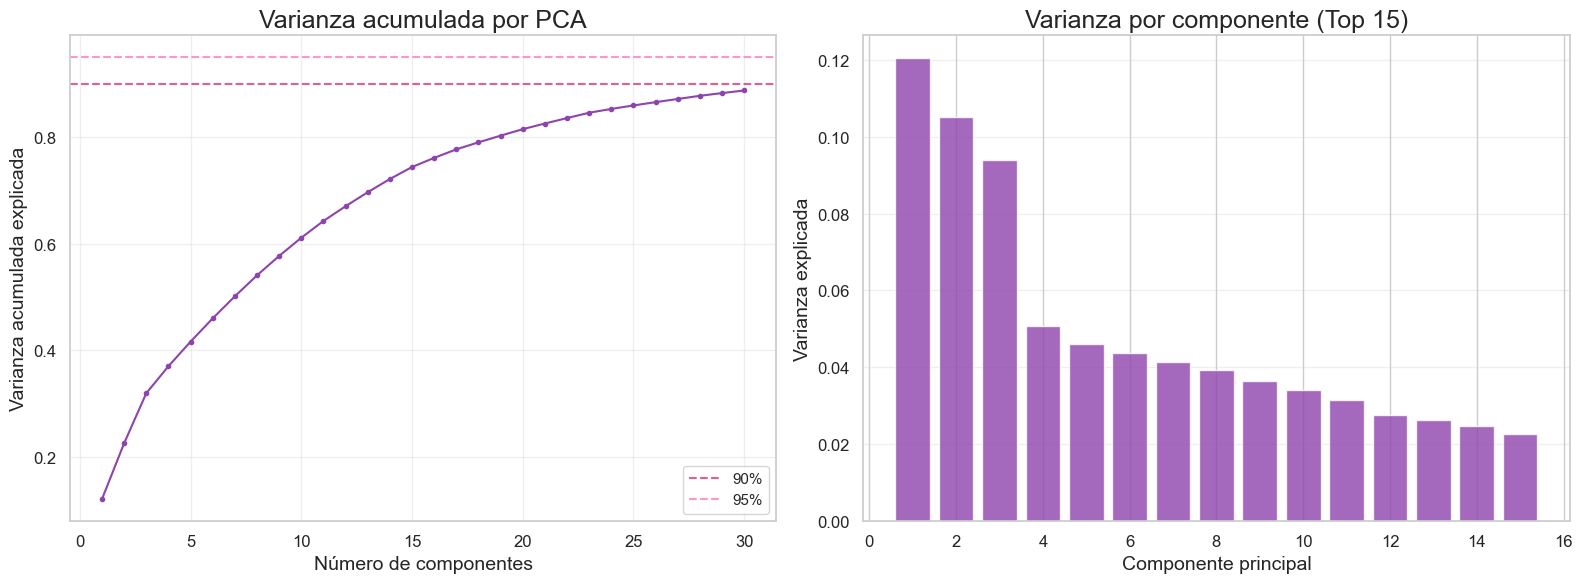

In [8]:
# ---------------------------
# PCA: varianza acumulada
# ---------------------------

# Primero exploramos cuántos componentes se necesitan para retener el 90% de varianza
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_sample)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90   = int(np.searchsorted(cumvar, 0.90)) + 1
n_95   = int(np.searchsorted(cumvar, 0.95)) + 1

print(f"Componentes para retener 90% de varianza: {n_90}")
print(f"Componentes para retener 95% de varianza: {n_95}")
print(f"Varianza explicada por PC1: {pca_full.explained_variance_ratio_[0]:.4f}")
print(f"Varianza explicada por PC2: {pca_full.explained_variance_ratio_[1]:.4f}")
print(f"Varianza explicada por PC1+PC2: {cumvar[1]:.4f}")

# ---------------------------
# Gráfico de varianza acumulada
# ---------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_show = min(30, len(cumvar))
axes[0].plot(range(1, n_show + 1), cumvar[:n_show], marker=".", color="#8e44ad")
axes[0].axhline(y=0.90, color="#d81b60", linestyle="--", alpha=0.7, label="90%")
axes[0].axhline(y=0.95, color="#ff69b4", linestyle="--", alpha=0.7, label="95%")
axes[0].set_xlabel("Número de componentes")
axes[0].set_ylabel("Varianza acumulada explicada")
axes[0].set_title("Varianza acumulada por PCA")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Varianza individual primeros 15 componentes
axes[1].bar(range(1, 16), pca_full.explained_variance_ratio_[:15], color="#8e44ad", alpha=0.8)
axes[1].set_xlabel("Componente principal")
axes[1].set_ylabel("Varianza explicada")
axes[1].set_title("Varianza por componente (Top 15)")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


### 7.1 Visualización de clusters en espacio PCA (2D)


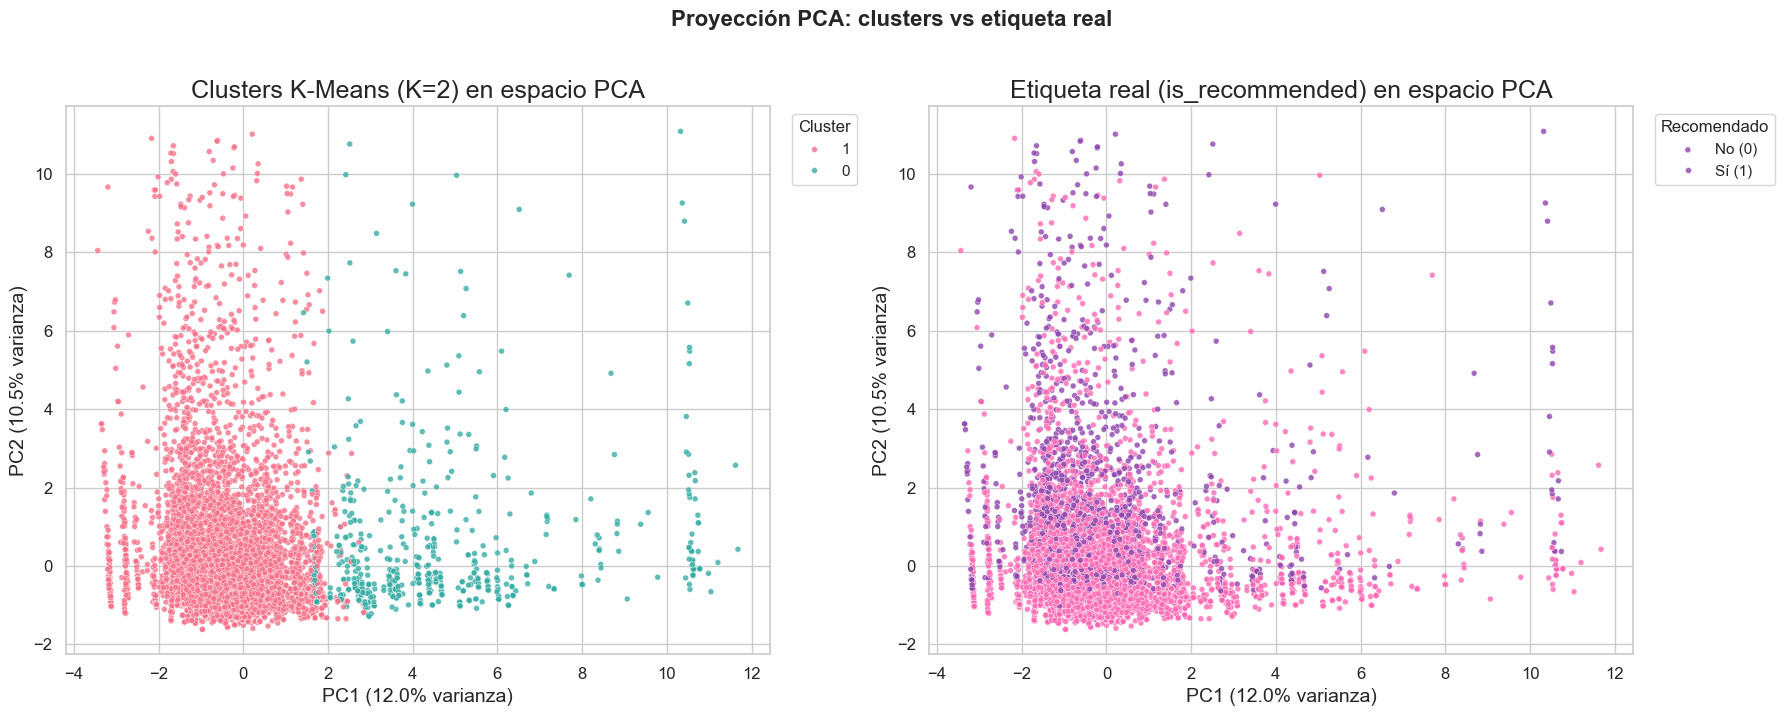


Varianza total explicada por PC1+PC2: 22.53%


In [10]:
# ---------------------------
# PCA a 2 componentes
# ---------------------------

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca  = pca_2d.fit_transform(X_sample)

df_plot = pd.DataFrame({
    "PC1":     X_pca[:, 0],
    "PC2":     X_pca[:, 1],
    "cluster": cluster_labels.astype(str),
})

# Muestra para visualización (evitar overplotting)
df_plot_sample = df_plot.sample(10_000, random_state=RANDOM_STATE)

# ---------------------------
# Scatter plot clusters
# ---------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

palette = sns.color_palette("husl", best_k)

# Izquierda: clusters K-Means
sns.scatterplot(
    data=df_plot_sample,
    x="PC1", y="PC2", hue="cluster",
    palette=palette, s=18, alpha=0.8, ax=axes[0],
)
axes[0].set_title(f"Clusters K-Means (K={best_k}) en espacio PCA")
axes[0].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)")
axes[0].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)")
axes[0].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# Derecha: colorear por is_recommended (etiqueta real)
df_plot_sample2 = df_plot_sample.copy()
df_plot_sample2["is_recommended"] = y_sample[
    df_plot_sample.index
]
df_plot_sample2["is_recommended"] = (
    df_plot_sample2["is_recommended"]
    .astype(int)
    .astype(str)
)

sns.scatterplot(
    data=df_plot_sample2,
    x="PC1", y="PC2", hue="is_recommended",
    palette={"0": "#8e44ad", "1": "#ff69b4"},
    s=18, alpha=0.8, ax=axes[1],
)
axes[1].set_title("Etiqueta real (is_recommended) en espacio PCA")
axes[1].set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)")
axes[1].set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)")
axes[1].legend(title="Recomendado", bbox_to_anchor=(1.02, 1), loc="upper left",
               labels=["No (0)", "Sí (1)"])

plt.suptitle("Proyección PCA: clusters vs etiqueta real", y=1.02, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nVarianza total explicada por PC1+PC2: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")


## 8. Perfil de clusters: relación con la variable objetivo

Aunque K-Means no utiliza `is_recommended` para agrupar, es valioso analizar si los clusters descubiertos presentan diferencias en la tasa de recomendación. Esto permite evaluar si las agrupaciones tienen **sentido de negocio**.


Perfil de clusters (tasa de recomendación):
         total  recomendados  pct_recomendado  pct_del_total
cluster                                                     
0         4060        3500.0            86.21           8.12
1        45940       38498.0            83.80          91.88


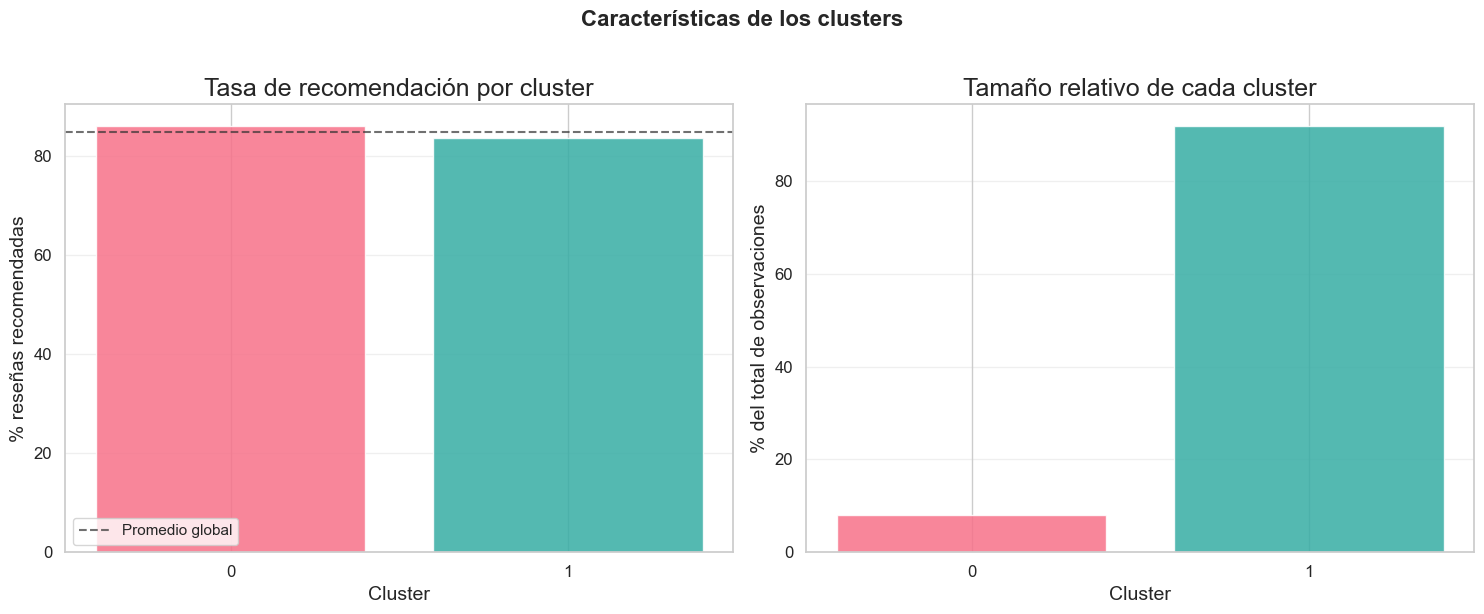

In [11]:
# ---------------------------
# Tasa de recomendación por cluster
# ---------------------------

cluster_profile = df_analysis.groupby("cluster")["is_recommended"].agg(
    total="count",
    recomendados="sum"
)
cluster_profile["pct_recomendado"] = (
    cluster_profile["recomendados"] / cluster_profile["total"] * 100
).round(2)
cluster_profile["pct_del_total"] = (
    cluster_profile["total"] / cluster_profile["total"].sum() * 100
).round(2)

print("Perfil de clusters (tasa de recomendación):")
print(cluster_profile.to_string())

# ---------------------------
# Gráfico de perfil
# ---------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Barras: % recomendado por cluster
colors = sns.color_palette("husl", best_k)
axes[0].bar(
    cluster_profile.index.astype(str),
    cluster_profile["pct_recomendado"],
    color=colors, alpha=0.85
)
axes[0].axhline(y=cluster_profile["pct_recomendado"].mean(),
                linestyle="--", color="#333", alpha=0.7, label="Promedio global")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("% reseñas recomendadas")
axes[0].set_title("Tasa de recomendación por cluster")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Barras: tamaño de cada cluster
axes[1].bar(
    cluster_profile.index.astype(str),
    cluster_profile["pct_del_total"],
    color=colors, alpha=0.85
)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("% del total de observaciones")
axes[1].set_title("Tamaño relativo de cada cluster")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Características de los clusters", y=1.02, fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


### 8.1 Interpretación del perfil

Los gráficos anteriores permiten responder: **¿Los clusters descubiertos automáticamente por K-Means coinciden con la etiqueta real?**

- Si los clusters presentan **tasas de recomendación muy diferentes** entre sí, el algoritmo logró capturar patrones que se alinean con el comportamiento real de los usuarios.
- Si las tasas son similares, los clusters representan otro tipo de segmentación (por ejemplo, por tipo de producto, nivel de gasto o perfil demográfico), igualmente válida para análisis exploratorio.


## 9. Persistencia de resultados

Se guardan las métricas del clustering y el modelo entrenado para su uso en notebooks posteriores (análisis final y comparación de modelos).


In [12]:
# ---------------------------
# Carpetas de resultados
# ---------------------------

metrics_dir = results_dir / "metrics"
plots_dir   = results_dir / "plots"
models_dir  = BASE_DIR / "models" / "trained_models"

for d in [metrics_dir, plots_dir, models_dir]:
    d.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Guardar métricas en JSON
# ---------------------------

unsupervised_metrics = {
    "best_k":               int(best_k),
    "best_silhouette_score": float(best_sil),
    "final_inertia":        float(kmeans_final.inertia_),
    "pca_variance_pc1":     float(pca_2d.explained_variance_ratio_[0]),
    "pca_variance_pc2":     float(pca_2d.explained_variance_ratio_[1]),
    "pca_variance_total_2d":float(pca_2d.explained_variance_ratio_.sum()),
    "components_for_90pct": int(n_90),
    "components_for_95pct": int(n_95),
    "k_results":            k_results.to_dict(orient="records"),
}

metrics_path = metrics_dir / "unsupervised_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(unsupervised_metrics, f, indent=2, ensure_ascii=False)

print(f"Métricas guardadas en: {metrics_path}")

# ---------------------------
# Guardar modelo K-Means
# ---------------------------

model_path = models_dir / "kmeans_best.pkl"
joblib.dump(kmeans_final, model_path, compress=3)
print(f"Modelo K-Means guardado en: {model_path}")

# ---------------------------
# Guardar PCA
# ---------------------------

pca_path = models_dir / "pca_2d.pkl"
joblib.dump(pca_2d, pca_path, compress=3)
print(f"Modelo PCA guardado en: {pca_path}")

print("\n✓ Todos los artefactos guardados correctamente.")


Métricas guardadas en: c:\Users\maria\OneDrive\Documentos\Informatica\Desarrollo de Aplicaciones Móviles\Proyectos\DataSet-Productos-Cosmeticos - copia\results\metrics\unsupervised_metrics.json
Modelo K-Means guardado en: c:\Users\maria\OneDrive\Documentos\Informatica\Desarrollo de Aplicaciones Móviles\Proyectos\DataSet-Productos-Cosmeticos - copia\models\trained_models\kmeans_best.pkl
Modelo PCA guardado en: c:\Users\maria\OneDrive\Documentos\Informatica\Desarrollo de Aplicaciones Móviles\Proyectos\DataSet-Productos-Cosmeticos - copia\models\trained_models\pca_2d.pkl

✓ Todos los artefactos guardados correctamente.


## 10. Conclusiones del análisis no supervisado

En este notebook se aplicaron técnicas de aprendizaje no supervisado sobre el dataset preprocesado de Sephora:

**K-Means Clustering:**
- Se evaluaron valores de K del 2 al 10 utilizando Inertia (Elbow Method) y Silhouette Score.
- El K óptimo fue seleccionado maximizando el Silhouette Score, lo que garantiza clusters con buena separación y cohesión interna.
- El análisis de perfil de clusters reveló diferencias en las tasas de recomendación entre grupos, lo que sugiere que K-Means capturó patrones relevantes del comportamiento de usuarios.

**PCA (Reducción de Dimensionalidad):**
- Se analizó la varianza acumulada para entender cuántos componentes son necesarios para retener el 90% y 95% de la información.
- La proyección 2D (PC1 + PC2) permitió visualizar la estructura de los clusters y compararla con la etiqueta real `is_recommended`.

**Relación con el modelado supervisado:**
- Los clusters descubiertos son complementarios al análisis supervisado: mientras los modelos de clasificación optimizan la predicción de `is_recommended`, el clustering explora la estructura subyacente sin depender de esa etiqueta.
- Esto permite detectar segmentos de usuarios o comportamientos que podrían ser relevantes para estrategias de negocio más allá de la simple clasificación.
